In [40]:
# Initialize Otter
import otter
grader = otter.Notebook("hw3-task2.ipynb")

# Homework 3 - Task 2: Tree-Based Methods
## Predicting Water Potability Using Decision Trees and Random Forests

---


### Dataset

Access to safe drinking water is a fundamental public health concern. This dataset contains physicochemical measurements for 3,276 water samples, each labeled as potable or non-potable.

| Feature | Description |
|---|---|
| `ph` | pH value of water (0–14 scale) |
| `Hardness` | Capacity to precipitate soap (mg/L) |
| `Solids` | Total dissolved solids (ppm) |
| `Chloramines` | Amount of chloramines (ppm) |
| `Sulfate` | Amount of sulfates dissolved (mg/L) |
| `Conductivity` | Electrical conductivity (μS/cm) |
| `Organic_carbon` | Amount of organic carbon (ppm) |
| `Trihalomethanes` | Amount of trihalomethanes (μg/L) |
| `Turbidity` | Measure of light-emitting property (NTU) |

#### Response Variable

| Column | Description |
|---|---|
| `Potability` | Binary flag — `1` if water is safe to drink, `0` otherwise |


 **Note:** Several features contain missing values (`ph`, `Sulfate`, `Trihalomethanes`). You will handle these in the preprocessing step.

 This dataset comes from Kaggle and can be found [here](https://www.kaggle.com/datasets/uom190346a/water-quality-and-potability).

### Setup: Load Libraries

Run the cell below to import all required packages.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.tree import plot_tree



### Step 1: Load the Data

Read `water_potability.csv` into a DataFrame. Preview the first few rows and confirm its shape.

In [42]:
df = pd.read_csv('water_potability.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (3276, 10)


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


### Step 2: Explore the Data

Before modeling, examine the distribution of your response variable and the number of NAs. Understanding both will guide preprocessing decisions.

In [43]:
# Distribution of the target
print(df['Potability'].value_counts())

Potability
0    1998
1    1278
Name: count, dtype: int64


In [44]:
# Check proportions of target 
print(df['Potability'].value_counts(normalize=True)) # Clearly unbalanced 

Potability
0    0.60989
1    0.39011
Name: proportion, dtype: float64


In [45]:
# Count NAs
print(df.isnull().sum())

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64


### Step 3: Preprocess the Data

Three features have missing values. A simple approach for tree-based methods is to **impute with the column median**. Impute the missing values using `df.fillna()`.Store your cleaned dataframe in a variable called `df_clean`. 

After imputation, split the data 70/30 into training and test sets, stratifying on `Potability` to preserve the class ratio in both splits.Store your results in `X_train`, `X_test`, `y_train`, and `y_test`.

In [46]:
# Common way to fix missing values is to impute
df_clean = df.fillna(df.median())

# Very no nulls 
print(df_clean.isnull().sum())

ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64


In [47]:
# Split features + target into predictors and response
X = df_clean.drop(columns = ["Potability"])
y = df_clean["Potability"]

# Split into train and test sets 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [48]:
grader.check("q1")

q1 results: All test cases passed!

### Step 4: Fit a Single Classification Tree

Start with an **unpruned** classification tree (no constraints on depth or leaf size). This gives a baseline and illustrates the overfitting problem that ensemble methods address.

Fit `DecisionTreeClassifier` with only `random_state=42` set (all other parameters at defaults). Report the tree depth in a variable named `tree_depth`. Calculate both the train accuracy and the test accuracy, storing the train accuracy in a variable called`dt_unpruned_acc_train` and the test accuracy in a variable called `dt_unpruned_acc_test`. 

In [49]:
# Fit unpruned tree
dt_unpruned = DecisionTreeClassifier(random_state = 42)
dt_unpruned.fit(X_train, y_train)

# Tree depth
tree_depth = dt_unpruned.get_depth()
dt_unpruned_acc_train = dt_unpruned.score(X_train, y_train)
dt_unpruned_acc_test  = dt_unpruned.score(X_test, y_test)

# Check what the accuracies and depth is
print(f"Tree depth: {tree_depth}")
print(f"Train accuracy: {dt_unpruned_acc_train:.2f}")
print(f"Test accuracy: {dt_unpruned_acc_test:.2f}")

Tree depth: 33
Train accuracy: 1.00
Test accuracy: 0.58


In [50]:
grader.check("q2")

q2 results: All test cases passed!

<!-- BEGIN QUESTION -->

>**Q1: How does the training accuracy and test accuracy differ? What does this mean about your model?**

The training accuracy is 1.00 while the test accuracy is 0.58, representing a difference of about 0.42. This means that the model is severely overfitting the training data.

<!-- END QUESTION -->

### Step 5: Tune Tree Depth with Cross-Validation

A fully grown tree memorizes the training data (better training accuracy, poor test accuracy). We need to find the right **depth** to prevent this. 

Using 5-fold cross-validation on the training set, compute mean CV accuracy for `max_depth` from 1 to 20. Identify the optimal depth using `np.argmax`, storing it in a variable called `optimal_depth`. Plot the CV Accuracy against the 20 different depths, adding a vertical line at the optimal depth. 

Optimal depth: 7
Best CV accuracy: 0.6389


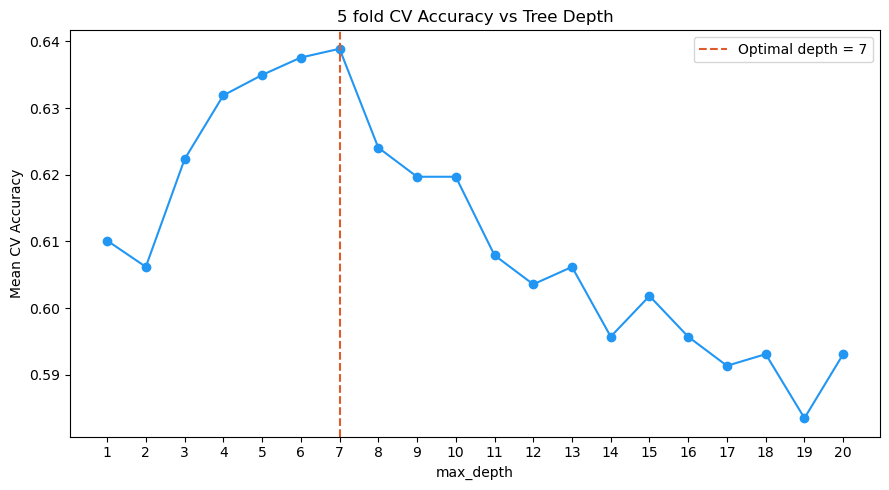

In [51]:
# Define range (goes to 21 to include 20)
depths = range(1,21)
cv_scores = []

for depth in depths:
    tree = DecisionTreeClassifier(max_depth = depth, random_state = 42)
    scores = cross_val_score(tree, X_train, y_train, cv=5, scoring="accuracy")
    cv_scores.append(scores.mean())

# Optimal depth 
optimal_depth = depths[np.argmax(cv_scores)]
print(f"Optimal depth: {optimal_depth}")
print(f"Best CV accuracy: {max(cv_scores):.4f}")

# Plot
plt.figure(figsize=(9, 5))
plt.plot(depths, cv_scores, marker="o", color="#2196F3")
plt.axvline(optimal_depth, color="#E05B2B", linestyle="--",
            label=f"Optimal depth = {optimal_depth}")
plt.xlabel("max_depth")
plt.ylabel("Mean CV Accuracy")
plt.title("5 fold CV Accuracy vs Tree Depth")
plt.xticks(depths)
plt.legend()
plt.tight_layout()
plt.show()

In [52]:
grader.check("q3")

q3 results: All test cases passed!

<!-- BEGIN QUESTION -->

> **Q2: What did cross fold validation find the optimal depth to be? Explain what these means in plain language.**

Cross validation found the optimal depth to be 7. This means that a depth of 7 gives the highest average accuracy across all these folds. With cross validation, we essentially test every depth from 1-20 and measure how well each one predicted data it has not been trained on (ie. unseen data) rather than running the tree to a depth of 33. A shallow tree (anything less than a depth of 7) would likely be too simple to capture enough of the data structure while a deeper trees would overfit the training data. 

<!-- END QUESTION -->

### Step 6: Fit the Tuned Decision Tree

Refit the decision tree using `optimal_depth` and evaluate on the held-out test set. Store the test accuracy in a variable called `acc_dt`. 

In [53]:
# Refit  tree using optimal depth 
dt_opt = DecisionTreeClassifier(max_depth = optimal_depth, random_state=42)
dt_opt.fit(X_train, y_train)

# Evaluate on test set
acc_dt = dt_opt.score(X_test, y_test)

print(f"Pruned tree (max_depth={optimal_depth}) test accuracy: {acc_dt:.4f}")

Pruned tree (max_depth=7) test accuracy: 0.6460


In [54]:
grader.check("q4")

q4 results: All test cases passed!

<!-- BEGIN QUESTION -->

>**Q3: Did the accuracy on your tuned decision tree imrpove compared to your untuned tree? If so, why do you think it improved?**

The accuracy of the tuned decision improved (test MSE of 0.58 to 0.64), likely because of limiting overfitting. More specifically, the untuned tree was growing to a depth of 33 with no contraints. As such, noise may have been absorbed from the training data, as well as patterns detected in the training data that cannot be generalized to new observations in unseen data. 

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

### Step 7: Visualize the Decision Tree

Plot the tuned tree using `plot_tree`. Save the tree as an image to evaluate the results and answer **Q5**. 

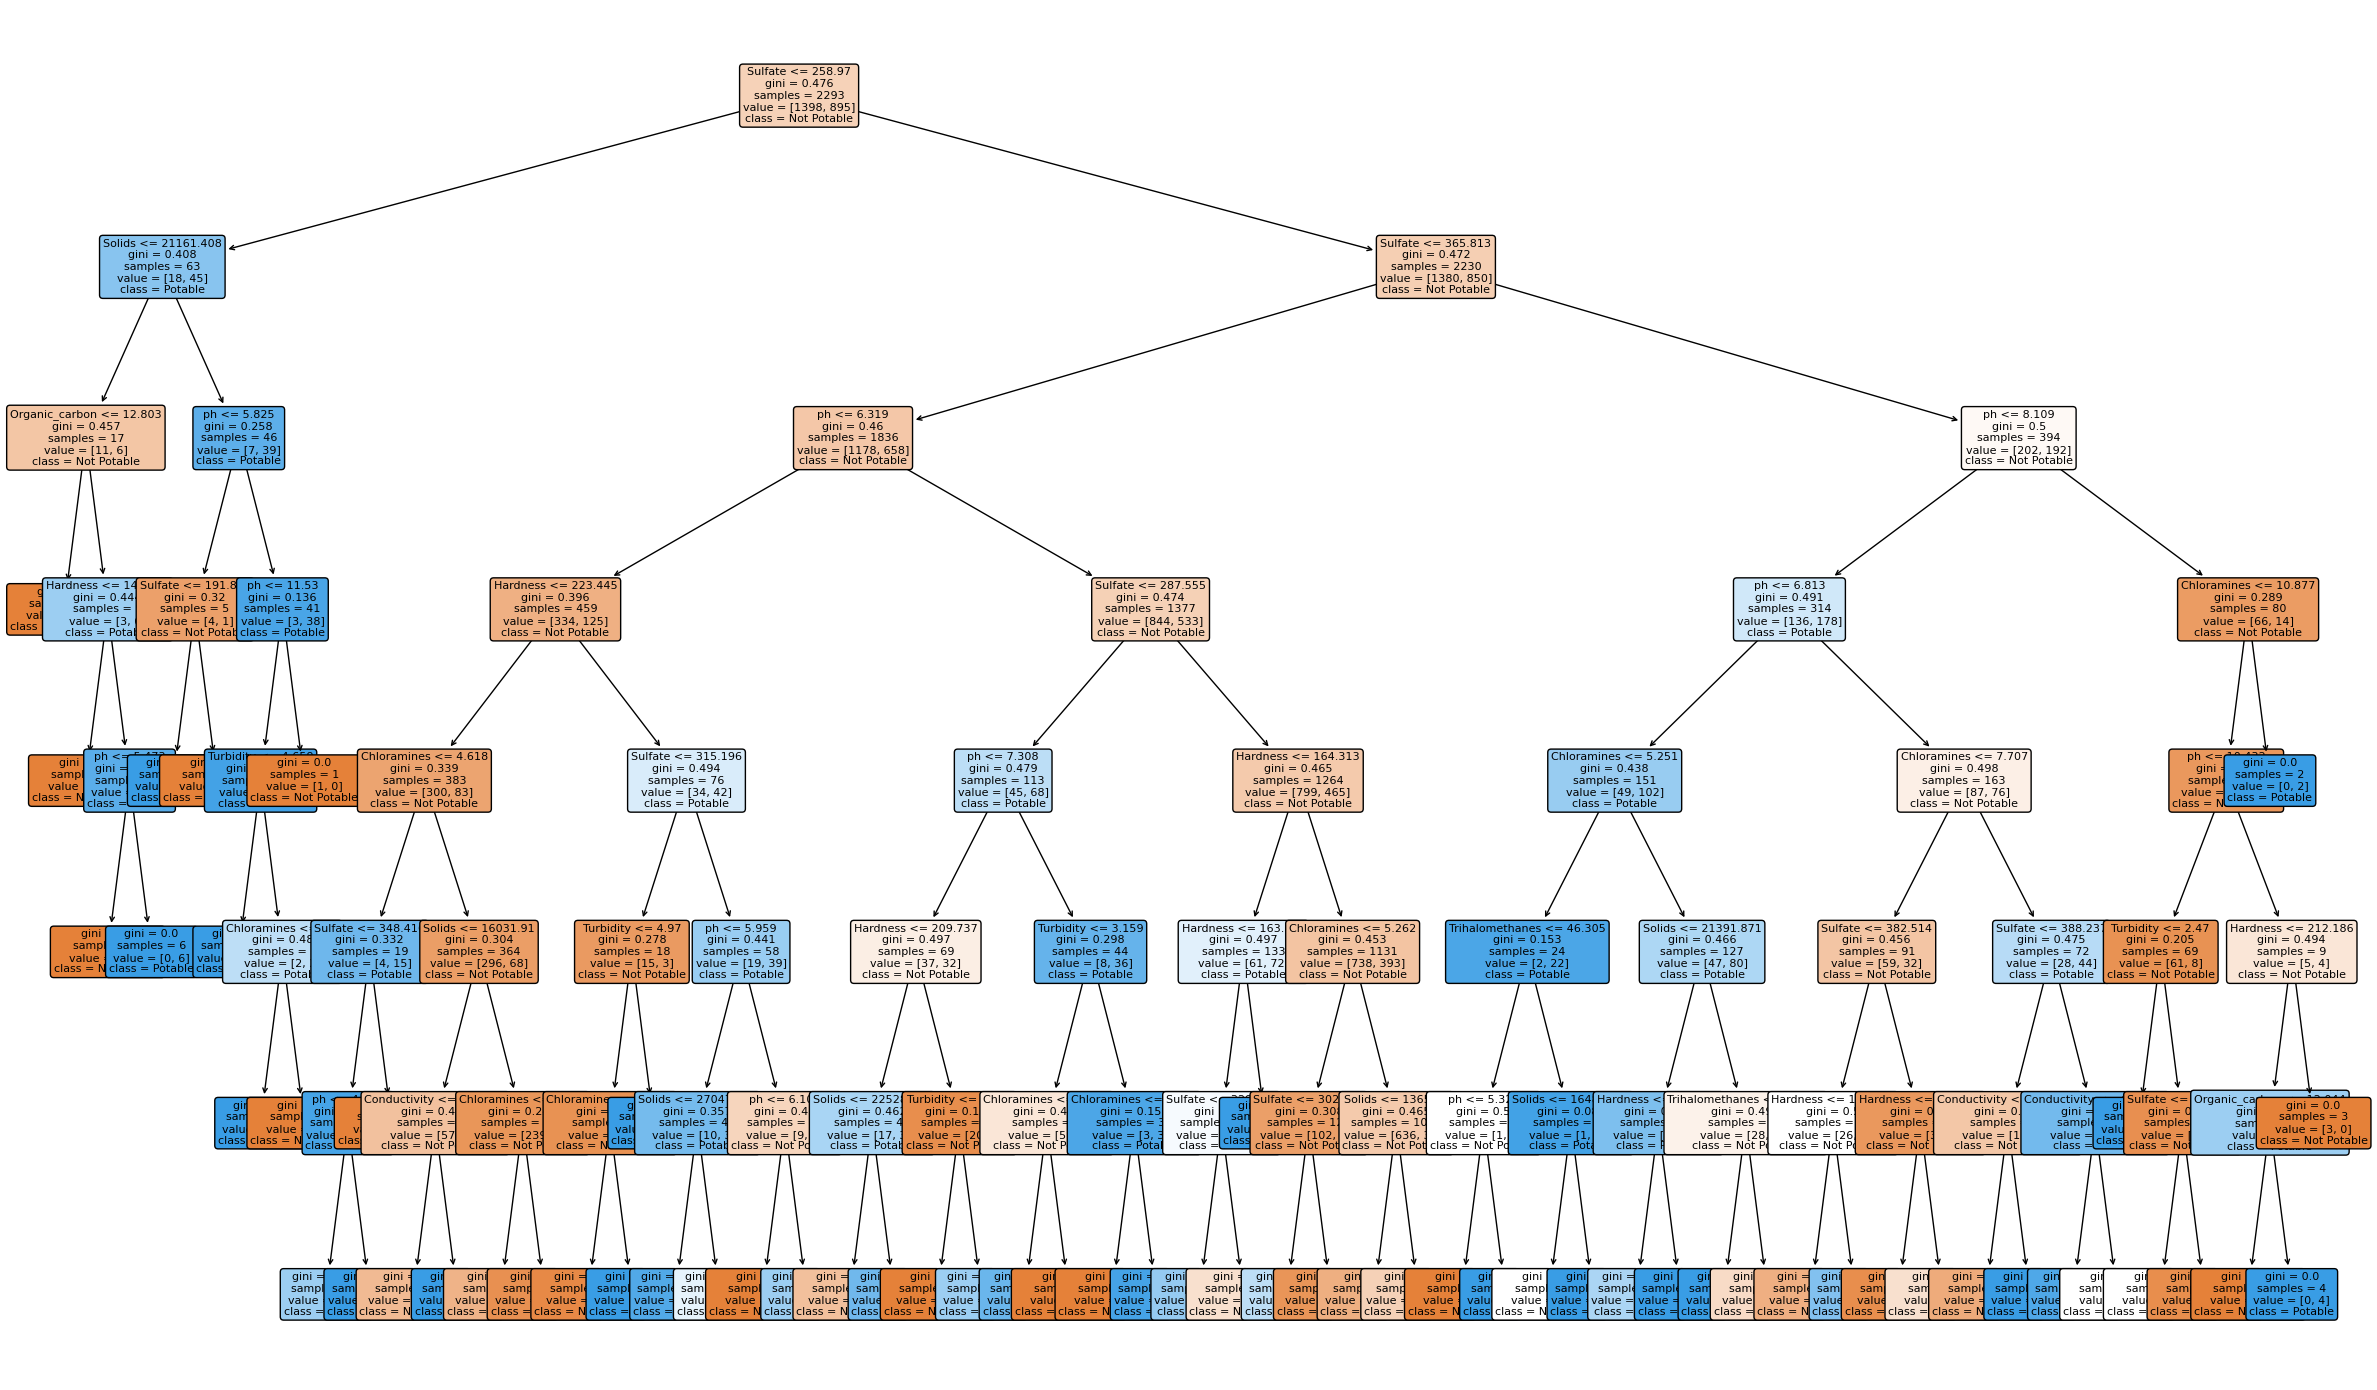

In [55]:
# Plot
fig, ax = plt.subplots(figsize=(24, 14))

# Create tree
plot_tree(
    dt_opt,
    feature_names= X_train.columns,
    class_names= ["Not Potable", "Potable"], # Classes
    filled=True,
    rounded=True,
    fontsize=8,
    ax=ax
)
plt.tight_layout()
plt.savefig("tuned_tree.png")
plt.show()

> **Q4: Examine the root node and first two levels of the tree. Which feature is used for the root split, and what threshold does it use? What does this tell you about that feature's relationship with potability? What is the Gini impurity at the root, and how does it change after the first split?**

The root node splits on Sulfate <= 258.97, signifying that sulfate is the "best" or most informative feature for predicting potability. Essentially, low-sulfate water is more likelyto be potable while higher-sulfate water is mostly likely not potable. The root Gini impurity is 0.476 and drops slightly to 0.408 on the low-sulfate branch and 0.472 on the higher-sulfate branch.

<!-- END QUESTION -->

### Step 8: Random Forest

**Random forests** address the high variance of a single tree by fitting many trees on bootstrap samples of the training data and averaging their predictions. To further reduce correlation among the trees, at each split only a random subset of $m$ features is considered (by default sklearn uses $m = \lfloor\sqrt{p}\rfloor$ for classification).

Fit a `RandomForestClassifier`, called `rf` with `n_estimators=200`. Report the accuracy and store it in `acc_rf`. 

In [61]:
# Fit random forest
rf = RandomForestClassifier(n_estimators = 200, random_state= 42)
rf.fit(X_train, y_train)

# Accuracy
acc_rf = rf.score(X_test, y_test)
print(f"Random Forest test accuracy: {acc_rf:.4f}")

Random Forest test accuracy: 0.6643


In [62]:
grader.check("q5")

q5 results:
    q5 - 1 result:
        ✅ Test case passed

    q5 - 2 result:
        ❌ Test case failed
        Trying:
            assert np.isclose(acc_rf, 0.6612, atol=0.001)
        Expecting nothing
        **********************************************************************
        Line 1, in q5 1
        Failed example:
            assert np.isclose(acc_rf, 0.6612, atol=0.001)
        Exception raised:
            Traceback (most recent call last):
              File "/opt/anaconda3/envs/eds232-env/lib/python3.10/doctest.py", line 1350, in __run
                exec(compile(example.source, filename, "single",
              File "<doctest q5 1[0]>", line 1, in <module>
                assert np.isclose(acc_rf, 0.6612, atol=0.001)
            AssertionError

<!-- BEGIN QUESTION -->

>**Q5: Compare the test results of Decision Tree and Random Forest? Which performed beter? Why do you think this is?**

The random forest performed better with a test accuracy of 0.66 because it combines 200 different trees trained on varied data and feature subsets (handles variance appropriately). By averaging predictions, the random forest reduces noise and overfitting.

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

### Step 9: Feature Importances

Both decision trees and random forests assign an **importance score** to each feature based on the total reduction in impurity (Gini) it produces across all splits. Random forest importances are averaged over all trees in the ensemble, making them more stable than a single tree's importances.

Create a bar plot showing the feature importances from the tuned decision tree and the random forest side by side. You can access the feature importants from the model wtih `model.feature_importances_`.

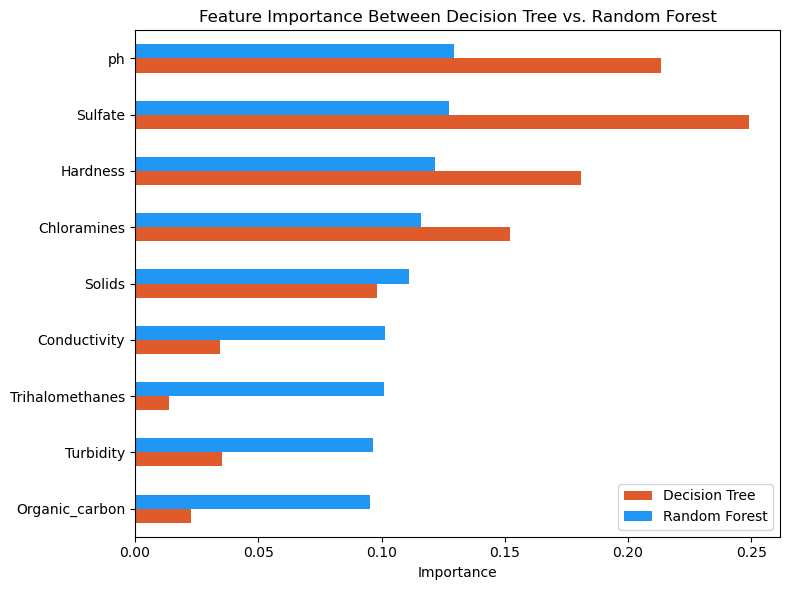

,Decision Tree,Random Forest
ph,0.213292,0.129314
Sulfate,0.249140,0.127526
Hardness,0.181002,0.121563
Chloramines,0.152269,0.116140
Solids,0.098077,0.111260
Conductivity,0.034332,0.101274
Trihalomethanes,0.013670,0.100835
Turbidity,0.035321,0.096608
Organic_carbon,0.022898,0.095479


In [66]:
# General idea is to plot two bars for each variable to compare between both models
# Feature importances 
imp_df = pd.DataFrame({
    "Decision Tree": dt_opt.feature_importances_,
    "Random Forest": rf.feature_importances_
}, index=X_train.columns)

# Put random forest first for table comparison (since had higher test accuracy)
imp_df = imp_df.sort_values("Random Forest")

# Grouped horizontal bars 
imp_df.plot(kind= "barh", figsize=(8, 6), color=["#E05B2B", "#2196F3"])
plt.xlabel("Importance")
plt.title("Feature Importance Between Decision Tree vs. Random Forest")
plt.tight_layout()
plt.show()

imp_df.sort_values("Random Forest", ascending= False)

> **Q6: Do the decision tree and random forest agree on which features are most important? If they differ, why might a single tree's importances be less reliable than the random forest's? Which feature appears most important for predicting potability, and does that make physical sense?**

Both models both agree on sulfate, pH, hardness, and chloramines ranking highest; however, the decision tree concentrates this importance on sulfate, pH, and hardness compared to the random forest spreading importance evenly. A single tree's importance would be less reliable because it assigns few splits from one training set. Essentially, the random forest averages 200 trees with random feature subsets and smooths out noise. The most important feature being sulfate for the decision tree and pH for the random forest makes physical sense because pH requires a "safe" range (6-8, cannot be too acidic or basic) and high sulfate could potentially cause significant health issues.

<!-- END QUESTION -->

### Step 10: Confusion Matrix

Create a confusion matrix for the random forest model using `ConfusionMatrixDisplay`. Label your response variable as `Not Potable`/ `Potable` in the confusion matrix (instead of `0`/`1`).

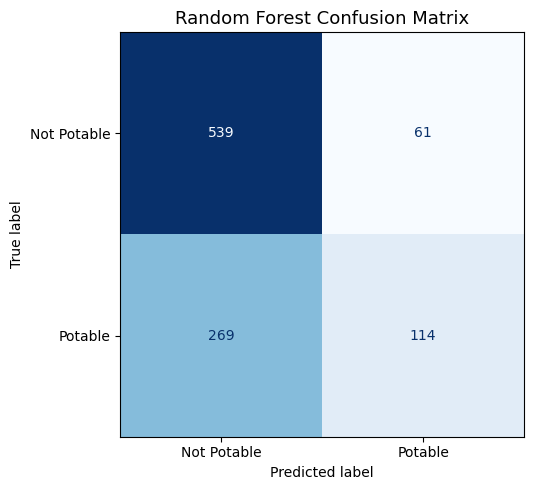

In [ ]:
# Taken from lab 3
y_pred_rf = rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Not Potable', 'Potable'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title("Random Forest Confusion Matrix", fontsize=13)
plt.tight_layout()
plt.show()

<!-- BEGIN QUESTION -->

> **Q7:** Report the results of the confusion matrix. How many false positives, true positives, false negatives, and true negatives did your model predict? Interpret what each of those 4 results means in the context of the data.

_Type your answer here, replacing this text._

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

### Step 11: Model Comparison

Create a table or bar chart comparing test accuracy across all three models.

In [ ]:
# Table 
results = pd.DataFrame({
    "Model": ["Decision Tree (unpruned)", "Decision Tree (tuned)", "Random Forest"],
    "Test Accuracy": [dt_unpruned_acc_test, acc_dt, acc_rf]
})
results    

,Model,Test Accuracy
0,Decision Tree (unpruned),0.580875
1,Decision Tree (tuned),0.645982
2,Random Forest,0.664293


> **Q8:** Which model achieved the highest test accuracy? Comparing the unpruned and tuned decision tree, how much did pruning improve accuracy? What does this tell you about overfitting in the unpruned tree?


The random forest resulted in the highest test accuracy at 0.664. Pruning improved accuracy by about .06. This improvement indicates that the unpruned was severely overfitting the training data; growing to a depth of 33 caused the model to memorize noise in the training data.

---

Run the cell below to receive credit for autograded questions. 

In [58]:
grader.check_all()

q1 results: All test cases passed!

q2 results: All test cases passed!

q3 results: All test cases passed!

q4 results: All test cases passed!

q5 results:
    q5 - 1 result:
        ✅ Test case passed

    q5 - 2 result:
        ❌ Test case failed
        Trying:
            assert np.isclose(acc_rf, 0.6612, atol=0.001)
        Expecting nothing
        **********************************************************************
        Line 1, in q5 1
        Failed example:
            assert np.isclose(acc_rf, 0.6612, atol=0.001)
        Exception raised:
            Traceback (most recent call last):
              File "/opt/anaconda3/envs/eds232-env/lib/python3.10/doctest.py", line 1350, in __run
                exec(compile(example.source, filename, "single",
              File "<doctest q5 1[0]>", line 1, in <module>
                assert np.isclose(acc_rf, 0.6612, atol=0.001)
            AssertionError